In [1]:
import cfgrib
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import re
import glob
import pandas as pd
from matplotlib.cm import get_cmap
from matplotlib.patches import Rectangle

# Prepare datafiles 
This script combines downloaded GRIB files containing static, surface, height and pressure level variables into one zarr and netcdf file (per month).
!Important: CERRA data is on a Lambert Conformal Conic (LCC) projected grid, not regular lat/lon.

### Merge

In [2]:
base = "/mnt/data/weatherloss/WindPower/data/cerra_boz/nc_boz"

surface_files  = sorted(glob.glob(os.path.join(base, "cerra_single_????_??_BOZ.nc")))
height_files   = sorted(glob.glob(os.path.join(base, "cerra_height_????_??_BOZ.nc")))
pressure_files = sorted(glob.glob(os.path.join(base, "cerra_pressure_????_??_BOZ.nc")))
static_file    = os.path.join(base, "cerra_static_BOZ.nc")

print(f"{len(surface_files)} surface files, {len(height_files)} height files, {len(pressure_files)} pressure files")

def _pp(ds):
    drop_candidates = ["valid_time", "step", "surface", "meanSea", "entireAtmosphere"]
    drops = [v for v in drop_candidates if v in ds.variables or v in ds.coords]
    return ds.drop_vars(drops, errors="ignore")

ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
ds_hgt = xr.open_mfdataset(height_files,   combine="by_coords", preprocess=_pp)
ds_prs = xr.open_mfdataset(pressure_files, combine="by_coords", preprocess=_pp)
ds_sta = xr.open_dataset(static_file)

t_start = "2020-01-01"
t_end   = "2025-07-31 21:00"

ds_sfc = ds_sfc.sel(time=slice(t_start, t_end))
ds_hgt = ds_hgt.sel(time=slice(t_start, t_end))
ds_prs = ds_prs.sel(time=slice(t_start, t_end))

# keep only orog + lsm if available
keep_static = [v for v in ["orog", "lsm"] if v in ds_sta]
ds_sta = ds_sta[keep_static]

67 surface files, 67 height files, 67 pressure files


/tmp/ipykernel_307578/2684607348.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
/tmp/ipykernel_307578/2684607348.py:15: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_sfc = xr.open_mfdataset(surface_files,  combine="by_coords", preprocess=_pp)
/tmp/ipykernel_3

In [3]:
cerra = xr.merge([ds_sta, ds_hgt, ds_prs, ds_sfc], compat="override", combine_attrs="drop")

### Add forcings 

In [4]:
def dir_to_sin_cos(da_deg: xr.DataArray):
    """Return sin, cos of a wind direction (degrees). Keeps dims/coords."""
    rad = np.deg2rad((da_deg % 360.0))
    return np.sin(rad), np.cos(rad)

year_len = xr.where(cerra.time.dt.is_leap_year, 366, 365)
doy_phase = 2*np.pi * (cerra.time.dt.dayofyear - 1) / year_len

cerra = cerra.assign(
    doy_sin = xr.DataArray(np.sin(doy_phase), dims=["time"], coords={"time": cerra.time},
                           attrs={"long_name":"sine of Julian day", "units":"1"}),
    doy_cos = xr.DataArray(np.cos(doy_phase), dims=["time"], coords={"time": cerra.time},
                           attrs={"long_name":"cosine of Julian day", "units":"1"}),
)

# Surface: wdir10  (time, y, x)
wdir10_sin, wdir10_cos = dir_to_sin_cos(cerra["wdir10"])

# Height levels: wdir  (time, heightAboveGround, y, x)
wdir_sin, wdir_cos = dir_to_sin_cos(cerra["wdir"])

wdir10_sin = wdir10_sin.assign_attrs(long_name="sine of 10m wind direction", units="1")
wdir10_cos = wdir10_cos.assign_attrs(long_name="cosine of 10m wind direction", units="1")
wdir_sin   = wdir_sin.assign_attrs(long_name="sine of wind direction", units="1")
wdir_cos   = wdir_cos.assign_attrs(long_name="cosine of wind direction", units="1")

cerra = cerra.assign(
    wdir10_sin = wdir10_sin,
    wdir10_cos = wdir10_cos,
    wdir_sin   = wdir_sin,
    wdir_cos   = wdir_cos,
)
cerra = cerra.drop_vars(["wdir10", "wdir"])

### Add synthetic wind power 

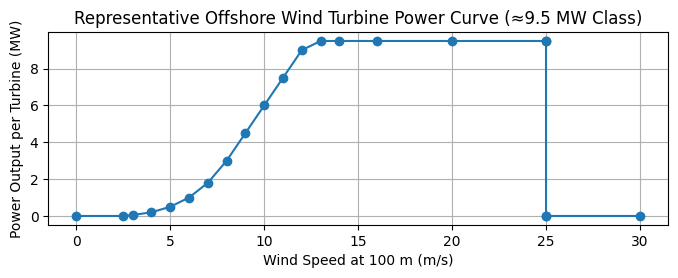

In [5]:
#add synthetic wind power with a power curve 
ws_pts = np.array([0.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                   11.0, 12.0, 13.0, 14.0, 16.0, 20.0, 24.99,24.999,25.0,25.01, 30.0], dtype="float32")
p_pts  = np.array([0.0, 0.0, 0.05, 0.20, 0.50, 1.00, 1.80, 3.00, 4.50, 6.00,
                   7.50, 9.00, 9.50, 9.50, 9.50, 9.50, 9.5,9.5,0.00,0.00, 0.00], dtype="float32")
plt.figure(figsize=(8, 2.5))
plt.plot(ws_pts, p_pts, marker='o', linestyle='-')
plt.xlabel("Wind Speed at 100 m (m/s)")
plt.ylabel("Power Output per Turbine (MW)")
plt.title("Representative Offshore Wind Turbine Power Curve (≈9.5 MW Class)")
plt.grid(True)
plt.show()
def interp_power(ws):
    return np.interp(ws, ws_pts, p_pts)

In [6]:
ws100 = cerra["ws"].sel(heightAboveGround=100.0)
synthetic_power = xr.apply_ufunc(
    np.interp,
    ws100,                # x
    xr.DataArray(ws_pts, dims="ws_pts"),
    xr.DataArray(p_pts,  dims="ws_pts"),
    input_core_dims=[[], ["ws_pts"], ["ws_pts"]],
    output_core_dims=[[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[np.float32],
)

In [7]:
synthetic_power.name = "synthetic_windpower"
synthetic_power.attrs = {
    "long_name": "Synthetic wind power from 100 m wind speed",
    "units": "MW per turbine",
    "description": "Derived from representative 9.5 MW-class power curve",
}

cerra = cerra.assign(synthetic_windpower=synthetic_power)

### Last tweaking and renaming

In [8]:
#flatten the height variables 
ds = cerra.copy()

# identify variables with the heightAboveGround dimension
vars_with_hag = [v for v in ds.data_vars if "heightAboveGround" in ds[v].dims]
print("Variables with heightAboveGround:", vars_with_hag)

# loop through them and split into separate variables
new_vars = {}
for v in vars_with_hag:
    for h in ds["heightAboveGround"].values:
        vname = f"{v}{int(h)}"  # e.g. ws50, ws100, wdir_cos150
        new_da = ds[v].sel(heightAboveGround=h).squeeze(drop=True)
        new_da.name = vname
        # update metadata for clarity
        new_da.attrs.update({
            "long_name": f"{v} at {int(h)} m",
            "height": int(h),
        })
        new_vars[vname] = new_da

# assign all new variables to the dataset
ds = ds.assign(**new_vars)

# drop the original 4D variables and the coordinate
ds = ds.drop_vars(vars_with_hag + ["heightAboveGround"])
ds = ds.rename({"isobaricInhPa": "level"})
cerra = ds

Variables with heightAboveGround: ['ws', 'wdir_sin', 'wdir_cos']


In [9]:
#last fixes
cerra = cerra.map(lambda x: x.astype("float32") if np.issubdtype(x.dtype, np.floating) else x)
cerra = cerra.assign_coords(
    longitude = ((cerra.longitude + 180) % 360) - 180
)

In [10]:
#convert orography to surface potential
g = 9.80665  # m s^-2 (standard gravity)
phis = (cerra["orog"].astype("float32") * g).assign_attrs(
    long_name="surface geopotential",
    units="m2 s-2",
    description="Φs = g * orography (height above mean sea level)"
)
cerra = cerra.drop_vars("orog").assign(surface_geopotential=phis)


In [11]:
cerra = cerra.rename({"si10": "ws10"})
cerra["ws10"].attrs.update({"long_name": "10 m wind speed", "units": "m s-1"})

### Sanity checks & then save

In [12]:
print(cerra.sizes)
print(cerra.coords["latitude"].min().item(), cerra.coords["latitude"].max().item())
print(cerra.coords["longitude"].min().item(), cerra.coords["longitude"].max().item())

Frozen({'y': 157, 'x': 211, 'time': 16312, 'level': 9})
48.17421306690378 56.710697262860165
-8.203234558354325 10.325340643754913


In [ ]:
cerra.to_netcdf("Cerra.nc", engine="netcdf4", mode="w")

In [ ]:
cerra = cerra.chunk({"time": 24, "y": 157, "x": 211})  # or adjust chunking for your workflow
cerra.to_zarr("Cerra.zarr", mode="w", consolidated=True)